In [2]:
!pip install requests beautifulsoup4 pandas lxml tqdm Sastrawi scikit-learn nltk matplotlib

  Using cached Sastrawi-1.0.1-py2.py3-none-any.whl (209 kB)
     ---------------------------------------- 8.3/8.3 MB 81.5 kB/s eta 0:00:00
     ---------------------------------------- 1.8/1.8 MB 74.1 kB/s eta 0:00:00
     ---------------------------------------- 9.3/9.3 MB 70.9 kB/s eta 0:00:00
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
     ------------------------------------- 306.1/306.1 kB 93.8 kB/s eta 0:00:00
     ------------------------------------- 474.0/474.0 kB 58.2 kB/s eta 0:00:00
     ------------------------------------- 125.3/125.3 kB 34.6 kB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ---------------------------------------- 2.5/2.5 MB 66.4 kB/s eta 0:00:00
     --------------------------------------- 70.7/70.7 kB 84.2 kB/s eta 0:00:00
     ---------------------------------------- 7.2/7.2 MB 75.0 kB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\PPW\\env_webmining\\Lib\\site-packages\\pyparsing\\__init__.py'
Check the permissions.


[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached Sastrawi-1.0.1-py2.py3-none-any.whl (209 kB)
  Using cached scikit_learn-1.9.1-cp311-cp311-win_amd64.whl (8.3 MB)
  Using cached nltk-3.10.3-py3-none-any.whl (1.8 MB)
     ---------------------------------------- 9.3/9.3 MB 69.9 kB/s eta 0:00:00
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
  Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)
  Using cached click-8.5.0-py3-none-any.whl (125 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached fonttools-4.65.0-cp311-cp311-win_amd64.whl (2.5 MB)
  Using cached kiwisolver-1.5.1-cp311-cp311-win_amd64.whl (70 kB)
     ---------------------------------------- 7.2/7.2 MB 92.9 kB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from tqdm import tqdm
import time
import re
import nltk
import matplotlib.pyplot as plt

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

Matplotlib is building the font cache; this may take a moment.


In [4]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to C:\Users\Assatya
[nltk_data]     Dewantara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
urls = [
    "https://finance.detik.com/fintech",
    "https://finance.detik.com/infrastruktur"
]

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/139.0.0.0 Safari/537.36"
}

for url in urls:
    response = requests.get(url, headers=headers, timeout=10)

    print("URL:", url)
    print("Status Code:", response.status_code)
    print("Panjang halaman:", len(response.text))
    print("-" * 50)

URL: https://finance.detik.com/fintech
Status Code: 200
Panjang halaman: 318961
--------------------------------------------------
URL: https://finance.detik.com/infrastruktur
Status Code: 200
Panjang halaman: 322388
--------------------------------------------------


In [6]:
for url in urls:
    response = requests.get(url, headers=headers, timeout=10)
    
    soup = BeautifulSoup(response.text, "html.parser")
    
    print("URL:", url)
    print("Judul halaman:", soup.title.get_text(strip=True))
    print("-" * 50)

URL: https://finance.detik.com/fintech
Judul halaman: Info Berita Terkini Fintech, Startup, Bitcoin
--------------------------------------------------
URL: https://finance.detik.com/infrastruktur
Judul halaman: detikFinance - Berita Ekonomi Bisnis, dan Investasi Hari Ini
--------------------------------------------------


In [7]:
data_link = []

for url in urls:
    response = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(response.text, "html.parser")
    
    links = soup.find_all("a", href=True)

    for link in links:
        href = link["href"]
        text = link.get_text(" ", strip=True)

        if "/fintech/" in href and "/d-" in href and text:
            kategori = "Fintech"

            data_link.append({
                "judul": text,
                "url": href,
                "kategori": kategori
            })

        elif "/infrastruktur/" in href and "/d-" in href and text:
            kategori = "Infrastruktur"

            data_link.append({
                "judul": text,
                "url": href,
                "kategori": kategori
            })

    print("Selesai crawling:", url)

df_link = pd.DataFrame(data_link)

# Hilangkan URL duplikat
df_link = df_link.drop_duplicates(subset="url")

# Reset index
df_link = df_link.reset_index(drop=True)

print("Total artikel:", len(df_link))

df_link.head(10)

Selesai crawling: https://finance.detik.com/fintech
Selesai crawling: https://finance.detik.com/infrastruktur
Total artikel: 102


,judul,url,kategori
0,Nilai Transaksi Aset Kripto RI Turun 28% Jadi ...,https://finance.detik.com/fintech/d-8652464/ni...,Fintech
1,"Mendag Ungkap Cara RI Bentuk Bursa Mineral, Ti...",https://finance.detik.com/fintech/d-8636465/me...,Fintech
2,"Transaksi Kripto RI Tembus Rp 20,52 T",https://finance.detik.com/fintech/d-8636301/tr...,Fintech
3,"Bitcoin Masih Diminati Investor, Ini Tandanya",https://finance.detik.com/fintech/d-8655330/bi...,Fintech
4,Keuntungan Gadai BPKB Motor Saat Kebutuhan Dan...,https://finance.detik.com/fintech/d-8646895/ke...,Fintech
5,6 Cara Memilih Aplikasi Pinjaman Online Bunga ...,https://finance.detik.com/fintech/d-8644968/6-...,Fintech
6,"Bitcoin Terbang ke Level US$ 80.000, Ini Penye...",https://finance.detik.com/fintech/d-8637573/bi...,Fintech
7,Bisalunas Ungkap 6 Mitos Galbay Pinjol yang Wa...,https://finance.detik.com/fintech/d-8634417/bi...,Fintech
8,"Industri Kripto Masuk Babak Baru, Regulasi dan...",https://finance.detik.com/fintech/d-8632680/in...,Fintech
9,"Pengguna Kripto RI Tembus 22 Juta, Industri Bu...",https://finance.detik.com/fintech/d-8630795/pe...,Fintech


In [8]:
print("Jumlah link:", len(df_link))

Jumlah link: 102


In [9]:
df_link

,judul,url,kategori
0,Nilai Transaksi Aset Kripto RI Turun 28% Jadi ...,https://finance.detik.com/fintech/d-8652464/ni...,Fintech
1,"Mendag Ungkap Cara RI Bentuk Bursa Mineral, Ti...",https://finance.detik.com/fintech/d-8636465/me...,Fintech
2,"Transaksi Kripto RI Tembus Rp 20,52 T",https://finance.detik.com/fintech/d-8636301/tr...,Fintech
3,"Bitcoin Masih Diminati Investor, Ini Tandanya",https://finance.detik.com/fintech/d-8655330/bi...,Fintech
4,Keuntungan Gadai BPKB Motor Saat Kebutuhan Dan...,https://finance.detik.com/fintech/d-8646895/ke...,Fintech
...,...,...,...
97,Stasiun Karet-BNI City Bakal Tersambung Travel...,https://finance.detik.com/infrastruktur/d-8642...,Infrastruktur
98,Danantara Buka Opsi Tawarkan Tukar Unit ke Kon...,https://finance.detik.com/infrastruktur/d-8641...,Infrastruktur
99,Rencana Besar KAI Rombak Stasiun Gambir,https://finance.detik.com/infrastruktur/d-8641...,Infrastruktur
100,154 Gardu Perlintasan Sebidang Dibangun buat C...,https://finance.detik.com/infrastruktur/d-8640...,Infrastruktur


In [10]:
df_artikel = df_link[
    (
        df_link["url"].str.contains("/fintech/", na=False)
        |
        df_link["url"].str.contains("/infrastruktur/", na=False)
    )
    &
    df_link["url"].str.contains("/d-", na=False)
].copy()

# Hilangkan URL duplikat
df_artikel = df_artikel.drop_duplicates(subset="url")

# Reset index
df_artikel = df_artikel.reset_index(drop=True)

print("Jumlah artikel fintech + infrastruktur:", len(df_artikel))

Jumlah artikel fintech + infrastruktur: 102


In [11]:
df_artikel.head(10)

,judul,url,kategori
0,Nilai Transaksi Aset Kripto RI Turun 28% Jadi ...,https://finance.detik.com/fintech/d-8652464/ni...,Fintech
1,"Mendag Ungkap Cara RI Bentuk Bursa Mineral, Ti...",https://finance.detik.com/fintech/d-8636465/me...,Fintech
2,"Transaksi Kripto RI Tembus Rp 20,52 T",https://finance.detik.com/fintech/d-8636301/tr...,Fintech
3,"Bitcoin Masih Diminati Investor, Ini Tandanya",https://finance.detik.com/fintech/d-8655330/bi...,Fintech
4,Keuntungan Gadai BPKB Motor Saat Kebutuhan Dan...,https://finance.detik.com/fintech/d-8646895/ke...,Fintech
5,6 Cara Memilih Aplikasi Pinjaman Online Bunga ...,https://finance.detik.com/fintech/d-8644968/6-...,Fintech
6,"Bitcoin Terbang ke Level US$ 80.000, Ini Penye...",https://finance.detik.com/fintech/d-8637573/bi...,Fintech
7,Bisalunas Ungkap 6 Mitos Galbay Pinjol yang Wa...,https://finance.detik.com/fintech/d-8634417/bi...,Fintech
8,"Industri Kripto Masuk Babak Baru, Regulasi dan...",https://finance.detik.com/fintech/d-8632680/in...,Fintech
9,"Pengguna Kripto RI Tembus 22 Juta, Industri Bu...",https://finance.detik.com/fintech/d-8630795/pe...,Fintech


In [12]:
df_artikel = df_artikel.head(102)

print("Jumlah artikel yang akan di-crawl:", len(df_artikel))

Jumlah artikel yang akan di-crawl: 102


In [13]:
df_artikel.tail()

,judul,url,kategori
97,Stasiun Karet-BNI City Bakal Tersambung Travel...,https://finance.detik.com/infrastruktur/d-8642...,Infrastruktur
98,Danantara Buka Opsi Tawarkan Tukar Unit ke Kon...,https://finance.detik.com/infrastruktur/d-8641...,Infrastruktur
99,Rencana Besar KAI Rombak Stasiun Gambir,https://finance.detik.com/infrastruktur/d-8641...,Infrastruktur
100,154 Gardu Perlintasan Sebidang Dibangun buat C...,https://finance.detik.com/infrastruktur/d-8640...,Infrastruktur
101,"Stasiun Gambir Bakal Dipermak Besar-besaran, N...",https://finance.detik.com/infrastruktur/d-8640...,Infrastruktur


In [14]:
hasil_scraping = []

for i, row in tqdm(df_artikel.iterrows(), total=len(df_artikel)):
    url = row["url"]
    
    try:
        response = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(response.text, "html.parser")
        
        # Ambil judul
        judul = soup.find("h1")
        judul = judul.get_text(" ", strip=True) if judul else ""
        
        # Ambil isi artikel
        artikel = soup.find("div", class_="detail__body-text")
        
        if artikel:
            isi = artikel.get_text(" ", strip=True)
        else:
            isi = ""
        
        hasil_scraping.append({
            "judul": judul,
            "url": url,
            "isi": isi
        })
        
        time.sleep(1)
        
    except Exception as e:
        print(f"Gagal scraping: {url}")
        print("Error:", e)

df_scraping = pd.DataFrame(hasil_scraping)

print("Jumlah artikel berhasil:", len(df_scraping))

100%|██████████| 102/102 [02:38<00:00,  1.56s/it]

Jumlah artikel berhasil: 102


In [15]:
df_scraping.head()

,judul,url,isi
0,Nilai Transaksi Aset Kripto RI Turun 28% Jadi ...,https://finance.detik.com/fintech/d-8652464/ni...,Jakarta - Otoritas Jasa Keuangan (OJK) melapor...
1,"Mendag Ungkap Cara RI Bentuk Bursa Mineral, Ti...",https://finance.detik.com/fintech/d-8636465/me...,Jakarta - Pemerintah sedang membangun Bursa Mi...
2,"Transaksi Kripto RI Tembus Rp 20,52 T",https://finance.detik.com/fintech/d-8636301/tr...,Jakarta - Otoritas Jasa Keuangan (OJK) mencata...
3,"Bitcoin Masih Diminati Investor, Ini Tandanya",https://finance.detik.com/fintech/d-8655330/bi...,Jakarta - ETF Bitcoin spot di Amerika Serikat ...
4,Keuntungan Gadai BPKB Motor Saat Kebutuhan Dan...,https://finance.detik.com/fintech/d-8646895/ke...,Jakarta - Kehidupan sering kali tak selalu ber...


In [16]:
print(df_scraping.iloc[0]["isi"])

Jakarta - Otoritas Jasa Keuangan (OJK) melaporkan perkembangan aktivitas kripto pada Juli 2026 menunjukkan tren penurunan. Kepala Eksekutif Pengawas Inovasi Teknologi Sektor Keuangan, Aset Keuangan Digital, dan Aset Kripto OJK, Adi Budiarso menyampaikan nilai transaksi aset kripto mencapai Rp 20,52 triliun. Angka ini turun 28,2% secara bulanan (month-to-month/mtm). Adi menyebut pergerakan transaksi tersebut ditengarai mengikuti dinamika dan fluktuasi nilai transaksi aset kripto. SCROLL TO CONTINUE WITH CONTENT "Sementara itu pada bulan Juli 2026 ini juga, nilai transaksi aset kripto tercatat sebesar Rp 20,52 triliun. Ini adalah menurun 28,2% month-to-month," ujar Adi dalam konferensi pers RDKB Agustus secara online, Senin (7/9/2026). Penurunan juga terjadi pada transaksi derivatif aset keuangan digital (AKD). OJK mencatat nilai transaksi derivatif AKD sebesar Rp 3,41 triliun pada Juli 2026, turun 18,52% secara bulanan. ADVERTISEMENT Meski transaksi mengalami penurunan, OJK menilai kepe

In [17]:
print("Isi kosong:", (df_scraping["isi"] == "").sum())

Isi kosong: 0


In [18]:
print("Jumlah data:", len(df_scraping))
print("Kolom:", df_scraping.columns.tolist())

df_scraping.info()

Jumlah data: 102
Kolom: ['judul', 'url', 'isi']
<class 'pandas.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   judul   102 non-null    str  
 1   url     102 non-null    str  
 2   isi     102 non-null    str  
dtypes: str(3)
memory usage: 2.5 KB


In [19]:
print("JUDUL:")
print(df_scraping.iloc[0]["judul"])

print("\nURL:")
print(df_scraping.iloc[0]["url"])

print("\nISI ARTIKEL:")
print(df_scraping.iloc[0]["isi"])

JUDUL:
Nilai Transaksi Aset Kripto RI Turun 28% Jadi Rp 20,52 Triliun

URL:
https://finance.detik.com/fintech/d-8652464/nilai-transaksi-aset-kripto-ri-turun-28-jadi-rp-20-52-triliun

ISI ARTIKEL:
Jakarta - Otoritas Jasa Keuangan (OJK) melaporkan perkembangan aktivitas kripto pada Juli 2026 menunjukkan tren penurunan. Kepala Eksekutif Pengawas Inovasi Teknologi Sektor Keuangan, Aset Keuangan Digital, dan Aset Kripto OJK, Adi Budiarso menyampaikan nilai transaksi aset kripto mencapai Rp 20,52 triliun. Angka ini turun 28,2% secara bulanan (month-to-month/mtm). Adi menyebut pergerakan transaksi tersebut ditengarai mengikuti dinamika dan fluktuasi nilai transaksi aset kripto. SCROLL TO CONTINUE WITH CONTENT "Sementara itu pada bulan Juli 2026 ini juga, nilai transaksi aset kripto tercatat sebesar Rp 20,52 triliun. Ini adalah menurun 28,2% month-to-month," ujar Adi dalam konferensi pers RDKB Agustus secara online, Senin (7/9/2026). Penurunan juga terjadi pada transaksi derivatif aset keuanga

In [20]:
df_scraping.to_csv(
    "hasil_scraping_detik_finance.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Data berhasil disimpan sebagai hasil_scraping_detik_finance.csv")

Data berhasil disimpan sebagai hasil_scraping_detik_finance.csv


In [21]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_words = set(
    stopwords.words("indonesian")
)

print("Jumlah stopword:", len(stop_words))

Jumlah stopword: 757


In [22]:
def preprocessing_teks(teks):
    # Pastikan teks berupa string
    teks = str(teks)

    # Case folding
    teks = teks.lower()

    # Menghapus URL
    teks = re.sub(
        r"http\S+|www\S+",
        " ",
        teks
    )

    # Menghapus angka
    teks = re.sub(
        r"\d+",
        " ",
        teks
    )

    # Menghapus karakter selain huruf
    teks = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        teks
    )

    # Menghapus spasi berlebih
    teks = re.sub(
        r"\s+",
        " ",
        teks
    ).strip()

    # Tokenisasi sederhana
    tokens = teks.split()

    # Stopword removal
    tokens = [
        kata
        for kata in tokens
        if kata not in stop_words
    ]

    # Menggabungkan token
    teks = " ".join(tokens)

    # Stemming Bahasa Indonesia
    teks = stemmer.stem(teks)

    return teks

In [23]:
df_scraping["teks_preprocessing"] = (
    df_scraping["isi"]
    .apply(preprocessing_teks)
)

In [35]:
df_scraping[
    [
        "judul",
        "isi",
        "teks_preprocessing"
    ]
].head(3)

,judul,isi,teks_preprocessing
0,Nilai Transaksi Aset Kripto RI Turun 28% Jadi ...,Jakarta - Otoritas Jasa Keuangan (OJK) melapor...,jakarta otoritas jasa uang ojk lapor kembang a...
1,"Mendag Ungkap Cara RI Bentuk Bursa Mineral, Ti...",Jakarta - Pemerintah sedang membangun Bursa Mi...,jakarta perintah bangun bursa mineral komodita...
2,"Transaksi Kripto RI Tembus Rp 20,52 T",Jakarta - Otoritas Jasa Keuangan (OJK) mencata...,jakarta otoritas jasa uang ojk catat nilai tra...


In [25]:
print("SEBELUM:")
print(df_scraping.iloc[0]["isi"][:1000])

print("\nSETELAH PREPROCESSING:")
print(
    df_scraping.iloc[0]["teks_preprocessing"][:1000]
)

SEBELUM:
Jakarta - Otoritas Jasa Keuangan (OJK) melaporkan perkembangan aktivitas kripto pada Juli 2026 menunjukkan tren penurunan. Kepala Eksekutif Pengawas Inovasi Teknologi Sektor Keuangan, Aset Keuangan Digital, dan Aset Kripto OJK, Adi Budiarso menyampaikan nilai transaksi aset kripto mencapai Rp 20,52 triliun. Angka ini turun 28,2% secara bulanan (month-to-month/mtm). Adi menyebut pergerakan transaksi tersebut ditengarai mengikuti dinamika dan fluktuasi nilai transaksi aset kripto. SCROLL TO CONTINUE WITH CONTENT "Sementara itu pada bulan Juli 2026 ini juga, nilai transaksi aset kripto tercatat sebesar Rp 20,52 triliun. Ini adalah menurun 28,2% month-to-month," ujar Adi dalam konferensi pers RDKB Agustus secara online, Senin (7/9/2026). Penurunan juga terjadi pada transaksi derivatif aset keuangan digital (AKD). OJK mencatat nilai transaksi derivatif AKD sebesar Rp 3,41 triliun pada Juli 2026, turun 18,52% secara bulanan. ADVERTISEMENT Meski transaksi mengalami penurunan, OJK men

In [26]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(
    df_scraping["teks_preprocessing"]
)

In [27]:
kata_unik = vectorizer.get_feature_names_out()

print(
    "Jumlah seluruh kata unik:",
    len(kata_unik)
)

Jumlah seluruh kata unik: 3081


In [28]:
print(kata_unik[:100])

['aaplx' 'abadi' 'abai' 'abang' 'abdul' 'abipraya' 'academy' 'acara'
 'account' 'acd' 'act' 'activity' 'acu' 'ada' 'adaptif' 'adaptive' 'adcp'
 'adhi' 'adi' 'adil' 'admin' 'administrasi' 'administratif'
 'administrative' 'adopsi' 'adrianto' 'adu' 'advertisement' 'advisory'
 'aftech' 'ag' 'agam' 'agama' 'agenda' 'agreement' 'agregat' 'agresif'
 'agun' 'agung' 'agus' 'agustus' 'ahi' 'ahli' 'ahy' 'ai' 'air' 'aja'
 'ajaib' 'ajak' 'ajang' 'ajar' 'aji' 'aju' 'akademisi' 'akd' 'akibat'
 'akn' 'akomodasi' 'akselerasi' 'akses' 'aksesibilitas' 'aksi' 'aktif'
 'aktivasi' 'aktivitas' 'aktivtas' 'aktual' 'aku' 'akuisisi' 'akun'
 'akuntabilitas' 'akurat' 'alam' 'alamat' 'alami' 'alarm' 'alas' 'alat'
 'alexander' 'alhamdulillah' 'alias' 'alih' 'alir' 'alokasi' 'aloysia'
 'alphabet' 'altcoin' 'alternatif' 'alur' 'amal' 'aman' 'amanat' 'amanda'
 'amar' 'amarbank' 'amazon' 'ambang' 'ambarawa' 'ambil' 'ambisi']


In [29]:
TfidfVectorizer()

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

In [30]:
print(
    "Ukuran matriks TF-IDF:",
    tfidf_matrix.shape
)

Ukuran matriks TF-IDF: (102, 3081)


In [31]:
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=kata_unik
)

df_tfidf.head()

,aaplx,abadi,abai,abang,abdul,abipraya,academy,acara,account,acd,...,youth,youtube,yudhi,yudhono,yudhoyono,zein,zenix,zero,zona,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.058002,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.072658,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
tfidf_dense = tfidf_matrix.toarray()

pca = PCA(
    n_components=2
)

tfidf_pca = pca.fit_transform(
    tfidf_dense
)

print(
    "Ukuran sebelum PCA:",
    tfidf_dense.shape
)

print(
    "Ukuran setelah PCA:",
    tfidf_pca.shape
)

Ukuran sebelum PCA: (102, 3081)
Ukuran setelah PCA: (102, 2)


In [36]:
df_pca = pd.DataFrame(
    tfidf_pca,
    columns=["PC1", "PC2"]
)

df_pca["judul"] = df_scraping["judul"].values
df_pca["isi"] = df_scraping["isi"].values
df_pca["url"] = df_scraping["url"].values

df_pca.head(10)

,PC1,PC2,judul,isi,url
0,0.321396,-0.348928,Nilai Transaksi Aset Kripto RI Turun 28% Jadi ...,Jakarta - Otoritas Jasa Keuangan (OJK) melapor...,https://finance.detik.com/fintech/d-8652464/ni...
1,0.055573,-0.055568,"Mendag Ungkap Cara RI Bentuk Bursa Mineral, Ti...",Jakarta - Pemerintah sedang membangun Bursa Mi...,https://finance.detik.com/fintech/d-8636465/me...
2,0.340729,-0.343592,"Transaksi Kripto RI Tembus Rp 20,52 T",Jakarta - Otoritas Jasa Keuangan (OJK) mencata...,https://finance.detik.com/fintech/d-8636301/tr...
3,0.190369,0.531052,"Bitcoin Masih Diminati Investor, Ini Tandanya",Jakarta - ETF Bitcoin spot di Amerika Serikat ...,https://finance.detik.com/fintech/d-8655330/bi...
4,-0.047354,0.066203,Keuntungan Gadai BPKB Motor Saat Kebutuhan Dan...,Jakarta - Kehidupan sering kali tak selalu ber...,https://finance.detik.com/fintech/d-8646895/ke...
5,-0.018314,0.004729,6 Cara Memilih Aplikasi Pinjaman Online Bunga ...,"Jakarta - Saat membutuhkan dana mendesak, memi...",https://finance.detik.com/fintech/d-8644968/6-...
6,0.249527,0.554840,"Bitcoin Terbang ke Level US$ 80.000, Ini Penye...",Jakarta - Bitcoin (BTC) bergerak hingga menyen...,https://finance.detik.com/fintech/d-8637573/bi...
7,-0.063527,0.034455,Bisalunas Ungkap 6 Mitos Galbay Pinjol yang Wa...,Jakarta - Masih percaya utang pinjol akan hang...,https://finance.detik.com/fintech/d-8634417/bi...
8,0.288507,-0.251273,"Industri Kripto Masuk Babak Baru, Regulasi dan...",Jakarta - Industri kripto memasuki fase baru k...,https://finance.detik.com/fintech/d-8632680/in...
9,0.354571,-0.315468,"Pengguna Kripto RI Tembus 22 Juta, Industri Bu...",Jakarta - Indonesia tengah memperkuat ekosiste...,https://finance.detik.com/fintech/d-8630795/pe...


In [38]:
print(
    "Explained Variance Ratio:"
)

print(
    pca.explained_variance_ratio_
)

print(
    "\nTotal variance yang dipertahankan:"
)

print(
    pca.explained_variance_ratio_.sum()
)

Explained Variance Ratio:
[0.07591472 0.04399313]

Total variance yang dipertahankan:
0.11990785332861842


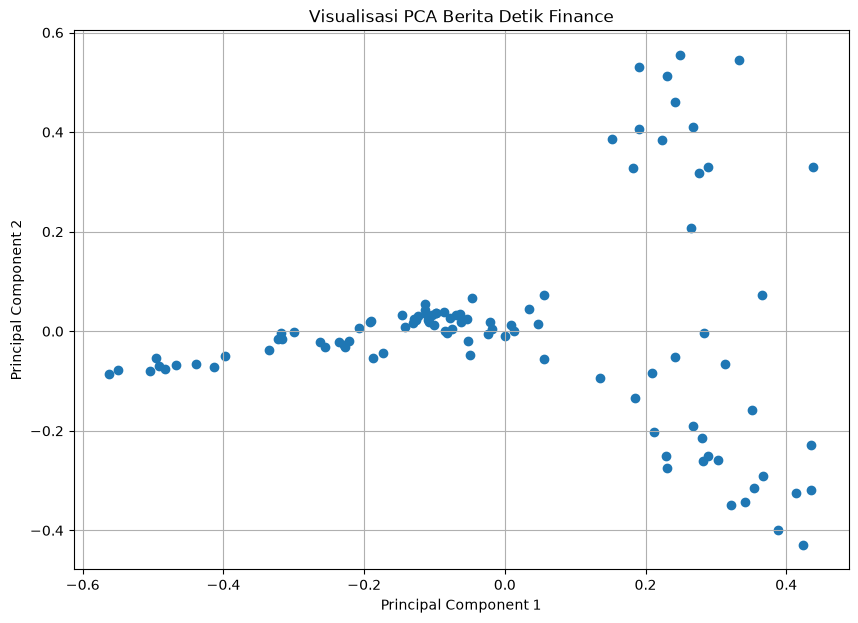

In [40]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Visualisasi PCA Berita Detik Finance")

plt.grid(True)

plt.show()

In [41]:
df_scraping.to_csv(
    "hasil_preprocessing_detik_finance.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Hasil preprocessing berhasil disimpan."
)

Hasil preprocessing berhasil disimpan.


In [42]:
df_pca.to_csv(
    "hasil_pca_detik_finance.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Hasil PCA berhasil disimpan."
)

Hasil PCA berhasil disimpan.


In [43]:
df_tfidf.to_csv(
    "hasil_tfidf_detik_finance.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Hasil TF-IDF berhasil disimpan."
)

Hasil TF-IDF berhasil disimpan.


In [44]:
import pandas as pd
import json

df = pd.read_csv("hasil_preprocessing_detik_finance.csv")

df.to_json(
    "hasil_preprocessing_detik_finance.json",
    orient="records",
    force_ascii=False,
    indent=2
)

print("JSON berhasil dibuat!")
print("Jumlah data:", len(df))

JSON berhasil dibuat!
Jumlah data: 102


In [45]:
import pandas as pd

df = pd.read_csv("hasil_tfidf_detik_finance.csv")

df.to_json(
    "hasil_tfidf_detik_finance.json",
    orient="records",
    force_ascii=False,
    indent=2
)

print("Jumlah data:", len(df))
print("Jumlah kolom:", len(df.columns))

Jumlah data: 102
Jumlah kolom: 3081


In [46]:
import pandas as pd

df = pd.read_csv("hasil_pca_detik_finance.csv")

df.to_json(
    "hasil_pca_detik_finance.json",
    orient="records",
    force_ascii=False,
    indent=2
)

print("Jumlah data:", len(df))
print("Kolom:", df.columns.tolist())

Jumlah data: 102
Kolom: ['PC1', 'PC2', 'judul', 'isi', 'url']
